# Proyecto TELECOM

## Código de solución

### 1.- Procesamiento y limpieza de datos

#### Importar librerías y datos

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
import shap


In [2]:
# Cargar los 4 archivos
df_contract = pd.read_csv("data/contract.csv")
df_personal = pd.read_csv("data/personal.csv")
df_internet = pd.read_csv("data/internet.csv")
df_phone = pd.read_csv("data/phone.csv")

# Unificar usando customerID tomando como base el archivo de información personal
df_final = df_contract.merge(df_personal, on="customerID", how="left")
df_final = df_final.merge(df_internet, on="customerID", how="left")
df_final = df_final.merge(df_phone, on="customerID", how="left")






In [3]:
df_final.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


In [4]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupport       5517 non-null   object 


In [5]:

print('Número de datos faltantes:')
print(df_final.isnull().sum())
print()
print('Número de entradas duplicadas:')
print(df_final.duplicated().sum())
print()
print('Número de customerIDs repetidos:')
print(len(df_final[df_final.duplicated(subset=['customerID'], keep=False)]))


Número de datos faltantes:
customerID             0
BeginDate              0
EndDate                0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64

Número de entradas duplicadas:
0

Número de customerIDs repetidos:
0


In [6]:
#Verificar si hay ceros en las columnas númericas

# Buscar cadenas de texto '0', '0.0' o espacios en blanco
ceros_texto = df_final["TotalCharges"].astype(str).str.strip().isin(["0", "0.0", ""])
print(f"Ceros o vacíos en formato texto: {ceros_texto.sum()}")


# Devuelve True si hay al menos un 0, False si no hay ninguno
hay_ceros = (df_final["MonthlyCharges"] == 0).any()
print(f"¿Hay ceros en MontlyCharges?: {hay_ceros}")


#Revisar si SeniorCitizen tiene valores diferentes a 1 y 0 para convertirlo a Object y así posteriormente codificarlo para los modelos de ML
print('Valores únicos de SeniorCitizen: ',df_final['SeniorCitizen'].unique())


Ceros o vacíos en formato texto: 11
¿Hay ceros en MontlyCharges?: False
Valores únicos de SeniorCitizen:  [0 1]


Usamos esta verificación para saber si explícitamente hay cero en TotalCharges, esto es útil para cambiarlos al igual que los NaN con el valor que tengan en MonthlyCharges que también se comprobó que no tiene NaNs ni ceros, ya que es lógico asumir que mínmamente se le hará un cargo mensual a este cliente antes de que pueda cancelar.

SeniorCitizen solo tiene dos valores, por lo cual puede convertirse a Object.

In [7]:
#Convertir SeniorCitizen a Object
df_final["SeniorCitizen"] = df_final["SeniorCitizen"].astype("object")

# Corregir 'TotalCharges'
df_final["TotalCharges"] = pd.to_numeric(df_final["TotalCharges"], errors="coerce")

# Convertir los valores 0 a NaN
df_final["TotalCharges"] = df_final["TotalCharges"].replace(0, np.nan)

# Si el cliente es nuevo TotalCharges suele ser NaN o 0.
# Podemos rellenar los NaN de TotalCharges con su valor de MontlyCharges
# 2. Rellenar los valores NaN de TotalCharges directamente con la columna MonthlyCharges
df_final["TotalCharges"] = df_final["TotalCharges"].fillna(df_final["MonthlyCharges"])


# Manejar valores nulos en servicios (Internet / Teléfono)
# Los nulos en servicios de Internet significan que 'No tienen servicio de Internet'
internet_cols = [
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]
for col in internet_cols:
    df_final[col] = df_final[col].fillna("No internet service")

# Los nulos en MultipleLines significan que 'No tienen servicio telefónico'
df_final["MultipleLines"] = df_final["MultipleLines"].fillna("No phone service")

# Convertir las fechas al formato adecuado
df_final["BeginDate"] = pd.to_datetime(df_final["BeginDate"])

# Para EndDate: si el cliente no se ha ido ('No'), asumimos la fecha del conjunto de datos que mencionan en Notion 01 de febrero del 2020
fecha_corte = pd.to_datetime("2020-02-01")

# Reemplazamos 'No' con la fecha de corte para poder restar fechas
df_final["EndDate_clean"] = df_final["EndDate"].replace("No", fecha_corte)
df_final["EndDate_clean"] = pd.to_datetime(df_final["EndDate_clean"])

# Calculamos los días de permanencia (Tenure)
df_final["TenureDays"] = (df_final["EndDate_clean"] - df_final["BeginDate"]).dt.days

# Eliminamos la columna temporal
df_final.drop(columns=["EndDate_clean"], inplace=True)

#Creación de la columna de interés Churn basado en sí hay fecha de término de contrato
df_final['Churn'] = (df_final['EndDate'] != 'No').astype(int)

# Eliminar customerID y las fechas ya que no es útil para entrenar modelos de ML
df_final.drop(columns=["customerID", "BeginDate", "EndDate"], inplace=True)




print(df_final.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Type              7043 non-null   object 
 1   PaperlessBilling  7043 non-null   object 
 2   PaymentMethod     7043 non-null   object 
 3   MonthlyCharges    7043 non-null   float64
 4   TotalCharges      7043 non-null   float64
 5   gender            7043 non-null   object 
 6   SeniorCitizen     7043 non-null   object 
 7   Partner           7043 non-null   object 
 8   Dependents        7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  MultipleLines     7043 non-null   object 


Se procesaron los datos en los cuales se realizó lo siguiente:

* Se identificaron y ajustaron los tipos de datos inconsistentes, como la fecha de incio y los cargos totales.
* No existen entradas ni IDs repetidos. Se rellenaron los datos faltantes en servicios con una etiqueta de no servicios contratados y se rellenaron los NaN y ceros de los cargos totales con el cargo mensual, ya que por lógica, mínimamente se le hará un cargo al cliente antes de cancelar.
* Se unificaron todos los archivos en un solo dataset utilizando el ID del cliente.
* Se creó la variable TenureDays que marca los días del contrato del cliente hasta una fecha establecida (para los casos en los que aún no cancelan) y con los días entre la fecha de inicio y fin de contrato para quien canceló. Además, se creo Churn, variable objetivo del presente proyecto para la predicción de si un cliente cancela o no.
* Se eliminaron las columnas con las fechas, ya que TenureDays es suficiente para captar esa información.

## 2.- Preparación de datos para el modelamiento

### Codificación de los atributos no númericos

In [8]:
#Crear una copia del dataset
df_encoded = df_final.copy()

# Identificar automáticamente las columnas tipo 'object'
cols_categoricas = df_encoded.select_dtypes(
    include=["object"]
).columns.tolist()

#Codificar las columnas categoricas con One-Hot-Encoding
df_encoded = pd.get_dummies(
    df_encoded, columns=cols_categoricas, drop_first=True, dtype=int
)

In [9]:
df_encoded.head()

,MonthlyCharges,TotalCharges,TenureDays,Churn,Type_One year,Type_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,...,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,MultipleLines_No phone service,MultipleLines_Yes
0,29.85,29.85,31,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0
1,56.95,1889.50,1036,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2,53.85,108.15,61,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,42.30,1840.75,1371,0,1,0,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
4,70.70,151.65,61,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


Se codificaron las columnas categoricas con One-Hot-Encoding eliminando un clase como es el estándar.

### Partición y escalamiento  de datos

In [10]:
#Particionar los datos en las características y variable objetivo
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

#Se particiona de forma estratificada para conservar las proporciones de clases

#Obtener conjunto de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
#Obtener conjunto de prueba y validación
X_valid, X_test, y_valid, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

print(f" - Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros | Validation: {X_valid.shape[0]} registros")

#Columnas a escalar 
cols_a_escalar = ["MonthlyCharges", "TotalCharges", "TenureDays"]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_valid_scaled = X_valid.copy()

# Fit + Transform solo en train
X_train_scaled[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])

# Transformar los conjuntos de prueba y validación
X_test_scaled[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])
X_valid_scaled[cols_a_escalar] = scaler.transform(X_valid[cols_a_escalar])

 - Train: 4225 registros | Test: 1409 registros | Validation: 1409 registros


Se dividieron los datos en los conjuntos de entrenamiento, prueba y validación (60/20/20).

### 3.-Modelamiento 

In [11]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train_scaled, y_train)

y_pred_dummy = dummy_clf.predict(X_test_scaled)
y_proba_dummy = dummy_clf.predict_proba(X_test_scaled)[:, 1]

print("=== MODELO BASELINE (Cota inferior) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dummy):.4f}")
print(
    f"Precision: {precision_score(y_test, y_pred_dummy, zero_division=0):.4f}"
)
print(f"Recall:    {recall_score(y_test, y_pred_dummy):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_dummy):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_dummy):.4f}\n")

=== MODELO BASELINE (Cota inferior) ===
Accuracy:  0.7346
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.5000



Se creó un modelo base Dummy que solo predice la clase mayoritaria para compararlo con el resto de modelos.
Como se observa el accuracy es de 0.73, la proporción de la clase mayoritaria (Churn = 0), mientras que el AUC-ROC de 0.5 indica que tiene un desempeño equivalente a tirar un moneda.

In [12]:
# Semilla global para reproducibilidad
SEED = 42

#Ratio de desbalance para utilizar en el parámetro de scale_pos_weight de LightGBM para que tome en cuenta el desbalanceo de clases.
ratio_desbalanceo = (y_train == 0).sum() / (y_train == 1).sum()


#Se crea un diccionario con los rangos de los parámetros en los que se utilizará GridSearch para buscar los mejores hipérparametros en ese rango
modelos_grid = {
    "Regresión Logística": {
        "model": LogisticRegression(
            class_weight="balanced", random_state=SEED, max_iter=1000
        ),
        "params": {
            "C": [0.01, 0.1, 1.0, 10.0],
            "penalty": ["l1", "l2"],
            "solver": ["liblinear"],
        },
    },
    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced", random_state=SEED
        ),
        "params": {
            "n_estimators": [100, 200, 300, 400],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5, 8],
        },
    },
    "LightGBM": {
        "model": lgb.LGBMClassifier(
            scale_pos_weight=ratio_desbalanceo, random_state=SEED
        ),
        "params": {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.1],
            "num_leaves": [20, 30, 40],
        },
    },
}

#Diccionario para guardar el modelo con los mejores hiperpárametros, se utiliza ROC-AUC como métrica a maximizar ya que suele ser la que mejor toma
#en cuenta el desbalanceo de clase en clasificación binaria
mejores_modelos = {}

#Aplicar el GridSearch a cada modelo
for nombre, config in modelos_grid.items():
    print(f"🔍 Optimizando {nombre}...")
    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        scoring="roc_auc",
        cv=5,
        n_jobs=-1,
    )
    grid.fit(X_train_scaled, y_train)

    mejores_modelos[nombre] = grid.best_estimator_
    print(f"   Mejor ROC-AUC en CV: {grid.best_score_:.4f}\n")





# Inicializamos la lista de resultados agregando primero el Modelo Dummy
resultados = [
    {
        "Modelo": "Baseline (Dummy)",
        "Accuracy": accuracy_score(y_test, y_pred_dummy),
        "Precision": precision_score(
            y_test, y_pred_dummy, zero_division=0
        ),  # zero_division evita advertencias por división entre 0
        "Recall": recall_score(y_test, y_pred_dummy),
        "F1-Score": f1_score(y_test, y_pred_dummy),
        "ROC-AUC": roc_auc_score(y_test, y_proba_dummy),
    }
]

#Evaluación de cada mejor modelo encontrado con el conjunto de prueba
for nombre, modelo in mejores_modelos.items():
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

    resultados.append(
        {
            "Modelo": nombre,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        }
    )

df_resultados = pd.DataFrame(resultados)
print("=== COMPARATIVA DE MÉTRICAS EN CONJUNTO DE PRUEBA ===")
display(df_resultados.round(4))



#Seleccionamos el ganador según mayor ROC-AUC en Test
nombre_ganador = df_resultados.sort_values(by="ROC-AUC", ascending=False).iloc[
    0
]["Modelo"]
modelo_ganador = mejores_modelos[nombre_ganador]

# Re-entrenamiento final con Train + Test
X_train_full = pd.concat([X_train_scaled, X_test_scaled])
y_train_full = pd.concat([y_train, y_test])
modelo_ganador.fit(X_train_full, y_train_full)

# Evaluación con el conjunto de validación
y_pred_valid = modelo_ganador.predict(X_valid_scaled)
y_proba_valid = modelo_ganador.predict_proba(X_valid_scaled)[:, 1]

print(f"\n🏆 MODELO GANADOR SELECCIONADO: {nombre_ganador}")
print("=== EVALUACIÓN EN CONJUNTO DE VALIDACIÓN FINAL ===")
print(f"Accuracy:  {accuracy_score(y_valid, y_pred_valid):.4f}")
print(f"Precision: {precision_score(y_valid, y_pred_valid):.4f}")
print(f"Recall:    {recall_score(y_valid, y_pred_valid):.4f}")
print(f"F1-Score:  {f1_score(y_valid, y_pred_valid):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_valid, y_proba_valid):.4f}")

🔍 Optimizando Regresión Logística...
   Mejor ROC-AUC en CV: 0.8448

🔍 Optimizando Random Forest...
   Mejor ROC-AUC en CV: 0.8552

🔍 Optimizando LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1121, number of negative: 3104
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 696
[LightGBM] [Info] Number of data points in the train set: 4225, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265325 -> initscore=-1.018470
[LightGBM] [Info] Start training from score -1.018470
   Mejor ROC-AUC en CV: 0.8873

=== COMPARATIVA DE MÉTRICAS EN CONJUNTO DE PRUEBA ===


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline (Dummy),0.7346,0.0000,0.0000,0.0000,0.5000
1,Regresión Logística,0.7431,0.5101,0.8102,0.6260,0.8328
2,Random Forest,0.7736,0.5560,0.7299,0.6312,0.8435
3,LightGBM,0.8197,0.6395,0.7353,0.6841,0.8798


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 706
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328

🏆 MODELO GANADOR SELECCIONADO: LightGBM
=== EVALUACIÓN EN CONJUNTO DE VALIDACIÓN FINAL ===
Accuracy:  0.8353
Precision: 0.6543
Recall:    0.8048
F1-Score:  0.7218
ROC-AUC:   0.9114


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Los resultados de los entrenamientos están correctos pero te recomendaría agregar visualizaciones para que la comparación sea más clara y fácil de comprender
</div>

Como se observa, el mejor modelo evaluado con el conjunto de prueba fue LightGBM, superando a los otros dos modelos en todas las métricas y con creces al modelo Dummy. Al elegirse como el mejor se entrenó con los conjuntos de entrenamiento y prueba y se valuó con el conjunto de validación obteniendo finalmente un ROC-AUC de 0.91, lo cual denota un adecuado desempeño en la clasificación binaria. Además, otras métricas destacar son las siguientes:

* El precision de 0.65 se interpreta como que 2 de cada 3 clientes que se predice que se irán realmente lo harán, siendo un tercio de falsos positivos.
* El recall de 0.8 indica que el modelo logra detectar 8 de cada 10 clientes que cancelarán, lo cual es un alto porcentaje de clientes a los que se puede atender a tiempo para evitar su deserción.

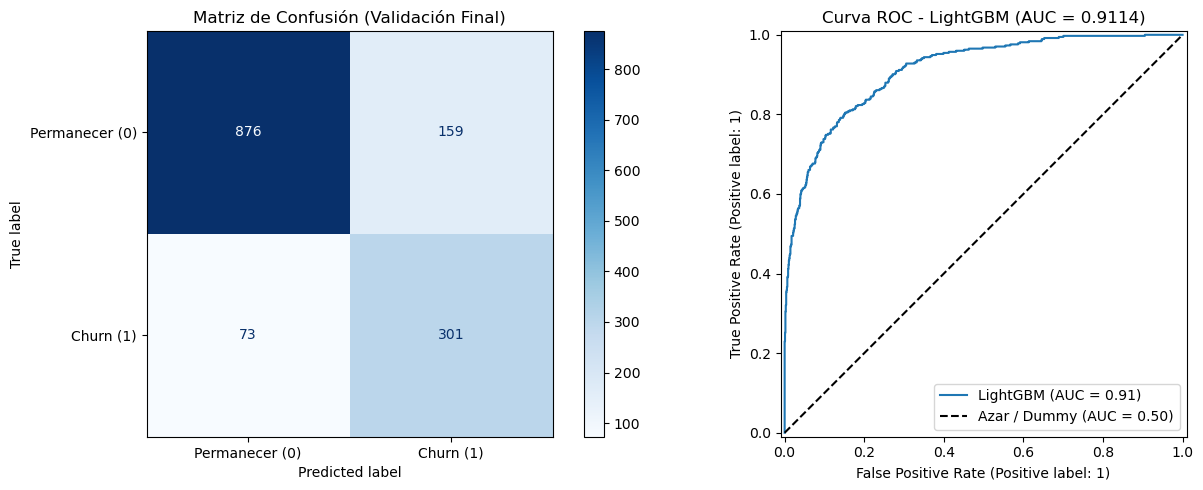

In [17]:
#Gráficos de la curva ROC y la matriz de confusión del modelo ganador
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred_valid,
    cmap="Blues",
    ax=axes[0],
    display_labels=["Permanecer (0)", "Churn (1)"],
)
axes[0].set_title("Matriz de Confusión (Validación Final)")

#Curva ROC
RocCurveDisplay.from_predictions(
    y_valid, y_proba_valid, ax=axes[1], name="LightGBM"
)
axes[1].plot([0, 1], [0, 1], "k--", label="Azar / Dummy (AUC = 0.50)")
axes[1].set_title(f"Curva ROC - LightGBM (AUC = {roc_auc_score(y_valid, y_proba_valid):.4f})")
axes[1].legend()

plt.tight_layout()
plt.show()

Como se logra observar, la curva ROC tiene un buen desempeño, sobresaliendo de la línea diagonal que sería un clasificación al azar, además, en la matriz de confusión la mayor parte de los casos se enceuntran en sus casillas adecuadas, siendo un bajo porcentaje los falsos positivos y negativos.

/tmp/ipykernel_9795/4143052763.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns_barplot = sns.barplot(


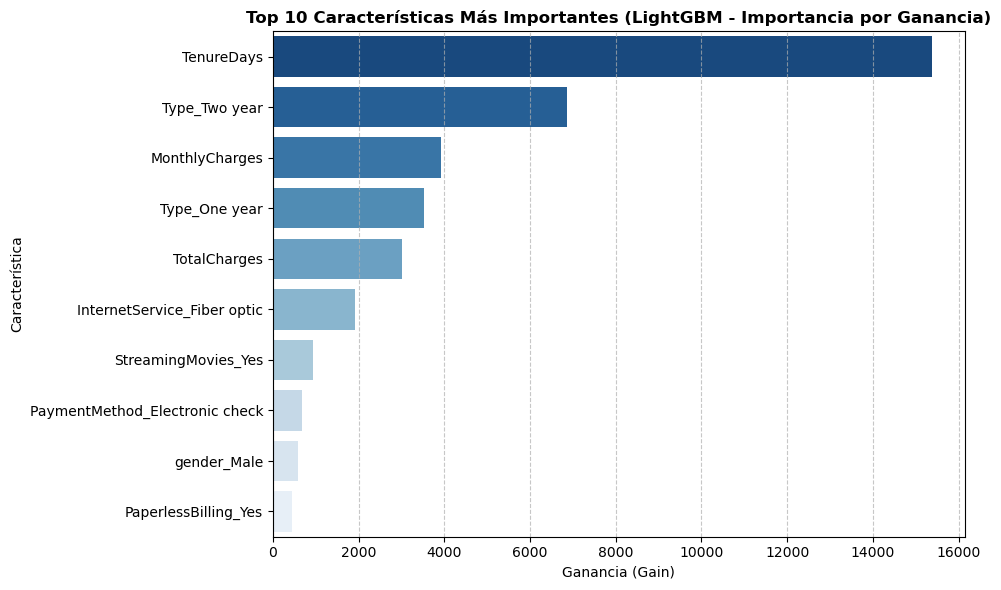

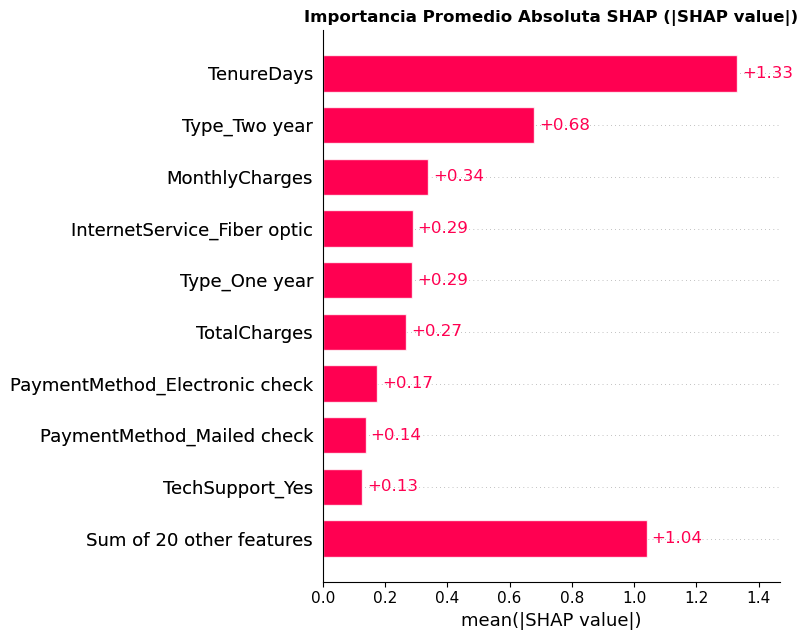

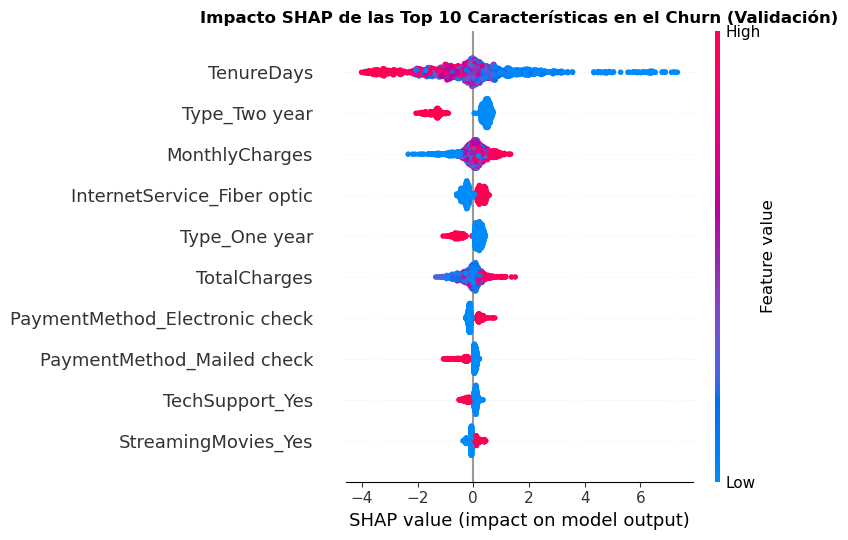

In [18]:
#Cálculo de la importancia de las características

# Utilizar la función feature importance de LightGBM
importancias = modelo_ganador.booster_.feature_importance(
    importance_type="gain"
)
nombres_features = X_valid_scaled.columns

df_importance = (
    pd.DataFrame(
        {"Caracteristica": nombres_features, "Ganancia de importancia": importancias}
    )
    .sort_values(by="Ganancia de importancia", ascending=False)
    .reset_index(drop=True)
)

# Graficar Top 10 características informativas
plt.figure(figsize=(10, 6))
sns_barplot = sns.barplot(
    data=df_importance.head(10),
    x="Ganancia de importancia",
    y="Caracteristica",
    palette="Blues_r",
)
plt.title(
    "Top 10 Características Más Importantes (LightGBM - Importancia por Ganancia)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Ganancia (Gain)", fontsize=10)
plt.ylabel("Característica", fontsize=10)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


#Análisis de importancia por características de SHAP

# Inicializar el explicador SHAP optimizado para modelos basados en árboles
explainer = shap.TreeExplainer(modelo_ganador)

# Calcular valores SHAP para el conjunto de validación
shap_values = explainer(X_valid_scaled)


# Gráfico de Barras SHAP (Magnitud promedio del impacto)

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=10, show=False)
plt.title(
    "Importancia Promedio Absoluta SHAP (|SHAP value|)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()



# Gráfico de Resumen SHAP (Beeswarm Plot)
# Muestra la importancia y la dirección del impacto en Churn
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_valid_scaled, max_display=10, show=False)
plt.title(
    "Impacto SHAP de las Top 10 Características en el Churn (Validación)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()



Los gráficos anteriores representan los siguiente:

* El primero muestra las características más importantes para LightGBM entrenado usando su propia función mientras el segundo calcula estas importancias utilizando SHAP, un algoritmo utilizado para la explicabilidad de modelos de IA.

* El tercer gráfico no solo muestra la importancia de cada característica sino además la intensidad de su influencia y la intensidad del valor en sí, esto lo hace por cada uno de los casos del conjunto de validación. Un ejemplo para aclarar:

    * La segunda característica más importante, "Type_Two year" es una variable de 0 y 1 indicando si se tiene un contrato de dos años. Como se puede observar, existen dos montículos de puntos, uno a la derecha del 0 indicando que su aportación hacia la predicción es positiva, es decir, en dirección al 1 de la variable objetivo, o sea, Churn = 1 (Cancelado) y el color de los puntos es azul, indicado que su valor es bajo, en este caso 0, lo que indicaría que estos casos no tienen un contrato de dos años. Caso contrario con el montículo a la izquierda del cero, que indica que su importancia es hacia la no cancelación y su valor es de 1, es decir, que sí tienen contrato de dos años. En resumen, lo que nos indica esos comportamientos que cuando un cliente no tienen un contrato de dos años es más probable que este cancele sus servicios.
 
Habiendo explicado la naturaleza de los gráficos, algunas de las características informativas que se observan son:

* Duración del contrato (TenureDays): Algo que se observó en el EDA, donde se veía un pico de cancelaciones en clientes que llevaban pocos meses con los servicios de la empresa.
* Contrato de dos años: Algo tambien observado en el EDA, los clientes que se quedaban tenían una mayor proporción de contratos a largo plazo.
* Cargos mensuales: Se podía ver en el EDA que los usarios que cancelaban tenían un mayor cargo mensual respecto a los que se quedaban.
* Fibra óptica, pago con cheque, Streaming de películas: Estas tres características también se observaron ser más comunes o altas en los cancelados en el EDA. El tema con el pago no automatizado es lo que podría estar generando cancelaciones involuntarias por olvido de envío o pago del cheque (algo que se teorizó en el EDA) y respecto a la renta de películas aparentemente tendría relación con que sus cargos mensuales fueran más elevados lo que derivaba en aumentar su descontento y cancelar sus servicios.

### 4.- Resumen de resultados

Los resultados más relevantes son:

* Se obtuvo un modelo con un desempeño bastante competente, siendo LightGBM con un AUC-ROC de calidación de 0.91.
* Las características relevantes detectadas, por dos diferentes métodos, tienen sentido lógico del porque un cliente podría cancelar, además que muchas de estas características se detecto su comportamiento desde el EDA y se teorizo que estas podrían ser las más relevantes.
* Se obtienen insights bastantes relavantes para detectar clientes en potencial riesgo de cancelación, lo cual le puede ayudar a los servicios de mercadeo de la empresa a implementar acciones para mejorar su satisfacción con la empresa, por ejemplo, incentivando con promociones a que las personas tengan un contrato a uno o dos años o que vinculen su tarjeta para el cobro automático, lo cual reduciría sus probabilidades generales de cancelar, ya sea activamente o involuntariamente por olvidar la fecha de pago.

A pesar de que el conjunto de datos estaba desbalanceado, implementar acciones en los modelos para contrarestar su efecto permitió obtener en todos los modelos desempeños destacables en métricas que toman en cuenta este desbalance como lo es ROC-AUC y F1, lo cual indica que se obtuvo un modelo robusto que puede servir para brindar explicaciones del comportamiento de los clientes basado en su información disponible.